In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import tensorflow as tf 
from tensorflow import keras 
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

In [2]:
df = pd.read_csv(r"../../Dataset/NCA Preprocessed/master_features_nca.csv")
df

,filename,cell_id,temp,charge_rate,discharge_rate,cycle,SOH,IC_bin_1,IC_bin_2,IC_bin_3,...,IC_bin_11,IC_bin_12,IC_bin_13,IC_bin_14,IC_bin_15,IC_bin_16,IC_bin_17,IC_bin_18,IC_bin_19,IC_bin_20
0,CY25-025_1-#1.csv,1,25,0.25,1.0,1,99.96,3.206253,3.435524,3.772510,...,4.255246,4.207070,4.229390,4.248806,4.264151,4.198406,4.058616,3.920543,3.792856,3.647914
1,CY25-025_1-#1.csv,1,25,0.25,1.0,2,99.98,3.185611,3.409977,3.737496,...,4.249921,4.223132,4.181276,4.225006,4.231327,4.158785,4.055173,3.905594,3.737473,3.648392
2,CY25-025_1-#1.csv,1,25,0.25,1.0,3,100.00,3.166235,3.397673,3.713245,...,4.235653,4.189766,4.140167,4.167926,4.180849,4.145106,4.015124,3.896722,3.756668,3.646670
3,CY25-025_1-#1.csv,1,25,0.25,1.0,4,99.97,3.139468,3.376350,3.683448,...,4.254307,4.162355,4.134256,4.143371,4.135573,4.118733,4.023064,3.867330,3.752034,3.631178
4,CY25-025_1-#1.csv,1,25,0.25,1.0,5,99.93,3.132129,3.346752,3.653736,...,4.216513,4.164974,4.094929,4.101335,4.135343,4.100581,4.008745,3.881142,3.761407,3.626212
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22639,CY45-05_1-#9.csv,9,45,0.50,1.0,411,84.65,2.514883,2.565545,2.627766,...,3.248165,3.376864,3.545380,3.705835,3.774339,3.705556,3.564230,3.413748,3.287599,3.193869
22640,CY45-05_1-#9.csv,9,45,0.50,1.0,412,84.61,2.510205,2.560754,2.625429,...,3.250500,3.392370,3.559592,3.706725,3.763518,3.694866,3.559024,3.417873,3.299083,3.207045
22641,CY45-05_1-#9.csv,9,45,0.50,1.0,413,84.60,2.513525,2.562124,2.623266,...,3.245492,3.372555,3.540142,3.694258,3.752898,3.692722,3.562536,3.425323,3.303745,3.206924
22642,CY45-05_1-#9.csv,9,45,0.50,1.0,414,84.58,2.508238,2.557557,2.619624,...,3.241048,3.372799,3.540815,3.700767,3.761809,3.701606,3.569719,3.425509,3.299934,3.202914


In [3]:
import sys
sys.path.append("../../")
from preprocessing.data_preprocessor import DataPreprocessor


preprocessor = DataPreprocessor(
    train_size=0.8,
    ic_low=0,
    ic_high=20
)

data = preprocessor.preprocess(df)

X_ic_train = data["X_ic_train"]
X_context_train = data["X_context_train"]
y_train = data["y_train"]


print("Train Data shape:")
print("X_ic_train shape:", X_ic_train.shape)
print("X_context_train shape:", X_context_train.shape)
print("y_train shape:",y_train.shape)


Train Data shape:
X_ic_train shape: (18109, 20, 1)
X_context_train shape: (18109, 7)
y_train shape: (18109,)


In [4]:
X_ic_test = data['X_ic_test']
X_context_test = data['X_context_test']
y_test_norm = data['y_test']

y_mean = data['y_mean']
y_std = data['y_std']

print("Test data shape:")
print("X_ic_test shape:", X_ic_test.shape)
print("X_context_test shape:", X_context_test.shape)
print("Y_test shape:", y_test_norm.shape)

Test data shape:
X_ic_test shape: (4528, 20, 1)
X_context_test shape: (4528, 7)
Y_test shape: (4528,)


jsma attack

In [5]:
import tensorflow as tf


@tf.function
def fast_jsma_regression_batch(
    model,
    x_ic,          # (B, 20, 1)
    x_ctx,         # (B, ctx_dim)
    scaler_std,    # (20,)
    delta_real=0.02,
    max_pairs=2,
    increase=True,
    clip_min=-3.0,
    clip_max=3.0,
):
    """
    Vectorized JSMA for regression SOH model.
    Returns adversarial IC curves (same shape as x_ic).
    """

    # ===== dtype safety =====
    x_ic = tf.cast(x_ic, tf.float32)
    x_ctx = tf.cast(x_ctx, tf.float32)
    scaler_std = tf.cast(scaler_std, tf.float32)
    delta_real = tf.cast(delta_real, tf.float32)
    clip_min = tf.cast(clip_min, tf.float32)
    clip_max = tf.cast(clip_max, tf.float32)

    B = tf.shape(x_ic)[0]
    n = tf.shape(x_ic)[1]

    # ===== start from clean =====
    x_adv = tf.identity(x_ic)

    # ===== feature-wise epsilon =====
    eps_scaled = delta_real / scaler_std
    eps_scaled = tf.reshape(eps_scaled, (1, n))
    eps_scaled = tf.tile(eps_scaled, [B, 1])

    # ===== track modified features =====
    modified = tf.zeros((B, n), dtype=tf.bool)

    direction = tf.constant(1.0 if increase else -1.0, tf.float32)
    extreme = tf.constant(-1e9 if increase else 1e9, tf.float32)

    # ================= JSMA LOOP =================
    for _ in tf.range(max_pairs):

        # ----- gradient of output wrt IC -----
        with tf.GradientTape() as tape:
            tape.watch(x_adv)
            y_pred = model([x_adv, x_ctx], training=False)

        grad = tape.gradient(y_pred, x_adv)      # (B,20,1)
        grad = tf.squeeze(grad, axis=-1)         # (B,20)

        # ----- sign constraint -----
        valid_sign = grad > 0 if increase else grad < 0

        # ----- pair saliency -----
        g_i = tf.expand_dims(grad, 2)
        g_j = tf.expand_dims(grad, 1)
        saliency = g_i + g_j                     # (B,20,20)

        # ----- invalid masks -----
        diag = tf.eye(n, batch_shape=[B], dtype=tf.bool)
        mod_i = tf.expand_dims(modified, 2)
        mod_j = tf.expand_dims(modified, 1)
        sign_i = tf.expand_dims(tf.logical_not(valid_sign), 2)
        sign_j = tf.expand_dims(tf.logical_not(valid_sign), 1)

        invalid = diag | mod_i | mod_j | sign_i | sign_j
        saliency = tf.where(invalid, extreme, saliency)

        # ----- best pair selection -----
        flat = tf.reshape(saliency, (B, -1))
        best_idx = tf.argmax(flat, axis=1) if increase else tf.argmin(flat, axis=1)
        best_idx = tf.cast(best_idx, tf.int32)

        n_int = tf.cast(n, tf.int32)
        i = best_idx // n_int
        j = best_idx % n_int

        # ----- epsilon updates -----
        eps_i = tf.gather(eps_scaled, i, batch_dims=1)
        eps_j = tf.gather(eps_scaled, j, batch_dims=1)

        updates_i = direction * eps_i
        updates_j = direction * eps_j

        # ----- scatter indices -----
        batch_idx = tf.range(B, dtype=tf.int32)
        zero_col = tf.zeros((B,), dtype=tf.int32)

        scatter_i = tf.stack([batch_idx, i, zero_col], axis=1)
        scatter_j = tf.stack([batch_idx, j, zero_col], axis=1)

        # ----- apply perturbation -----
        x_adv = tf.tensor_scatter_nd_add(x_adv, scatter_i, updates_i)
        x_adv = tf.tensor_scatter_nd_add(x_adv, scatter_j, updates_j)

        # ----- clip to valid IC range -----
        x_adv = tf.clip_by_value(x_adv, clip_min, clip_max)

        # ----- mark modified -----
        modified = tf.tensor_scatter_nd_update(
            modified, tf.stack([batch_idx, i], axis=1), tf.ones((B,), tf.bool)
        )
        modified = tf.tensor_scatter_nd_update(
            modified, tf.stack([batch_idx, j], axis=1), tf.ones((B,), tf.bool)
        )

    return x_adv


In [11]:
#-------Hyperparameters for attack-------
clip_min = np.percentile(X_ic_train, 0.5)
clip_max = np.percentile(X_ic_train, 99.5)

scaler_std = preprocessor.ic_scaler.scale_
deltas = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
pairs_list = [1, 2, 3, 4, 5, 6]



In [6]:
def plot_heatmap(matrix, title, deltas, pairs_list, cmap="turbo", annotate=True):
    plt.figure(figsize=(7, 5))

    im = plt.imshow(matrix, aspect="auto", cmap=cmap)

    cbar = plt.colorbar(im)
    cbar.ax.tick_params(labelsize=10)

    plt.xticks(range(len(pairs_list)), pairs_list, fontsize=11)
    plt.yticks(range(len(deltas)), deltas, fontsize=11)

    plt.xlabel("Max Pairs Modified", fontsize=12)
    plt.ylabel("Delta Real", fontsize=12)
    plt.title(title)

    if annotate:
        mean_val = np.mean(matrix)
        for i in range(matrix.shape[0]):
            for j in range(matrix.shape[1]):
                plt.text(
                    j, i,
                    f"{matrix[i, j]:.2f}",
                    ha="center",
                    va="center",
                    color="white" if matrix[i, j] < mean_val else "black",
                    fontsize=8,
                )

    plt.tight_layout()
    plt.show()


In [7]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
from tabulate import tabulate

def attack_evaluation(
    model,
    model_name,
    x_ic,
    x_ctx,
    y_true_norm,
    deltas,
    pairs_list,
    scaler_std,
    clip_min,
    clip_max,
    y_std,
    y_mean,
):
    
    # FIX: Ensure both inputs are Tensors to avoid mixing types
    x_ic = tf.convert_to_tensor(x_ic)
    x_ctx = tf.convert_to_tensor(x_ctx)

    # ===== clean prediction =====
    y_clean_norm = model([x_ic, x_ctx], training=False).numpy().flatten()

    y_true = y_true_norm * y_std + y_mean
    y_clean = y_clean_norm * y_std + y_mean

    # ----- clean metrics -----
    mae_clean = mean_absolute_error(y_true, y_clean)
    mse_clean = mean_squared_error(y_true, y_clean)

    # ===== Plot Clean Prediction (Once) =====
    plt.figure(figsize=(6, 5))
    plt.scatter(y_true, y_clean, s=8, alpha=0.7)
    min_v, max_v = y_true.min(), y_true.max()
    plt.plot([min_v, max_v], [min_v, max_v], "r--")
    plt.title(f"{model_name} — Clean Prediction\nMAE: {mae_clean:.4f}")
    plt.xlabel("True SOH")
    plt.ylabel("Predicted SOH")
    plt.grid(True)
    plt.show()

    # ===== heatmap storage =====
    MAE_map = np.zeros((len(deltas), len(pairs_list)))
    MAPE_map = np.zeros_like(MAE_map)

    table_rows = []

    # ===== Prepare Subplots for Adversarial Predictions =====
    n_rows = len(deltas)
    n_cols = len(pairs_list)
    
    # Create a grid of subplots
    # Adjust figsize: width = 4 * cols, height = 4 * rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), constrained_layout=True)
    
    # Ensure axes is always 2D array for consistent indexing
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes.reshape(1, -1)
    elif n_cols == 1:
        axes = axes.reshape(-1, 1)

    # ===== sweep =====
    for i, delta in enumerate(deltas):
        for j, pairs in enumerate(pairs_list):

            # --- JSMA attack ---
            x_adv = fast_jsma_regression_batch(
                model,
                x_ic,
                x_ctx,
                scaler_std,
                delta_real=delta,
                max_pairs=pairs,
                increase=True,
                clip_min=clip_min,
                clip_max=clip_max,
            )

            # --- prediction ---
            y_adv_norm = model([x_adv, x_ctx], training=False).numpy().flatten()
            y_adv = y_adv_norm * y_std + y_mean

            # --- metrics ---
            mae = mean_absolute_error(y_true, y_adv)
            mse = mean_squared_error(y_true, y_adv)
            mape = mean_absolute_percentage_error(y_true, y_adv)

            delta_mae = mae - mae_clean
            delta_mse = mse - mse_clean

            r2_drop = r2_score(y_true, y_adv) - r2_score(y_true, y_clean)

            # --- store ---
            MAE_map[i, j] = mae
            MAPE_map[i, j] = mape

            table_rows.append([
                delta,
                pairs,
                mse,
                mae,
                delta_mse,
                delta_mae,
                
            ])

            #print(f"Done → δ={delta}, pairs={pairs}")

            # --- Plot on Subplot ---
            ax = axes[i, j]
            ax.scatter(y_true, y_adv, s=8, color="orange", alpha=0.6)
            ax.plot([min_v, max_v], [min_v, max_v], "r--")
            ax.set_title(f"δ={delta}, pairs={pairs}\nMAE={mae:.4f}")
            
            # Only label outer axes
            if i == n_rows - 1:
                ax.set_xlabel("True SOH")
            if j == 0:
                ax.set_ylabel("Adv SOH")
            
            ax.grid(True)

    # Show the grid of adversarial plots
    plt.suptitle(f"{model_name} — JSMA Adversarial Sweep", fontsize=16)
    plt.show()

    # ===== print table =====
    headers = ["Delta", "Pairs", "MSE", "MAE", "ΔMSE", "ΔMAE", "Robustness"]

    print(f"\n=== JSMA Attack Results : {model_name} ===")
    print(tabulate(table_rows, headers=headers, floatfmt=".5f"))

    # ===== heatmaps =====
    plot_heatmap(MAE_map, f"{model_name} — MAE Heatmap", deltas, pairs_list, cmap = "plasma")
    plot_heatmap(MAPE_map, f"{model_name} — MAPE Heatmap", deltas, pairs_list, cmap = "plasma")

    return MAE_map, MAPE_map, table_rows


In [8]:
from tqdm import tqdm 

batch_size = 32

y_train_tf = y_train.reshape(-1,1).astype(np.float32)
y_test_tf = y_test_norm.reshape(-1,1).astype(np.float32)


In [9]:
X_context_test = tf.cast(X_context_test, tf.float32)


--------
CNN+LSTM
--------


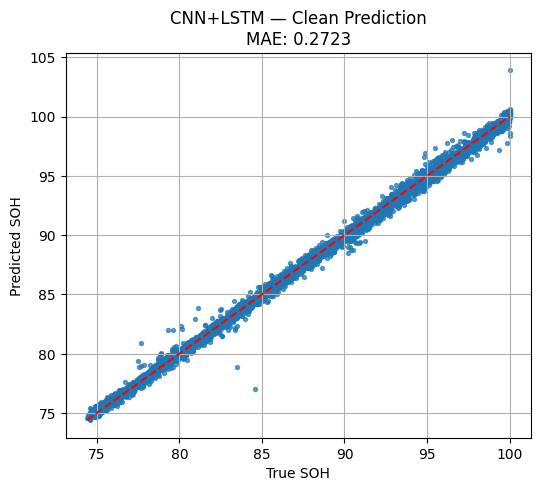

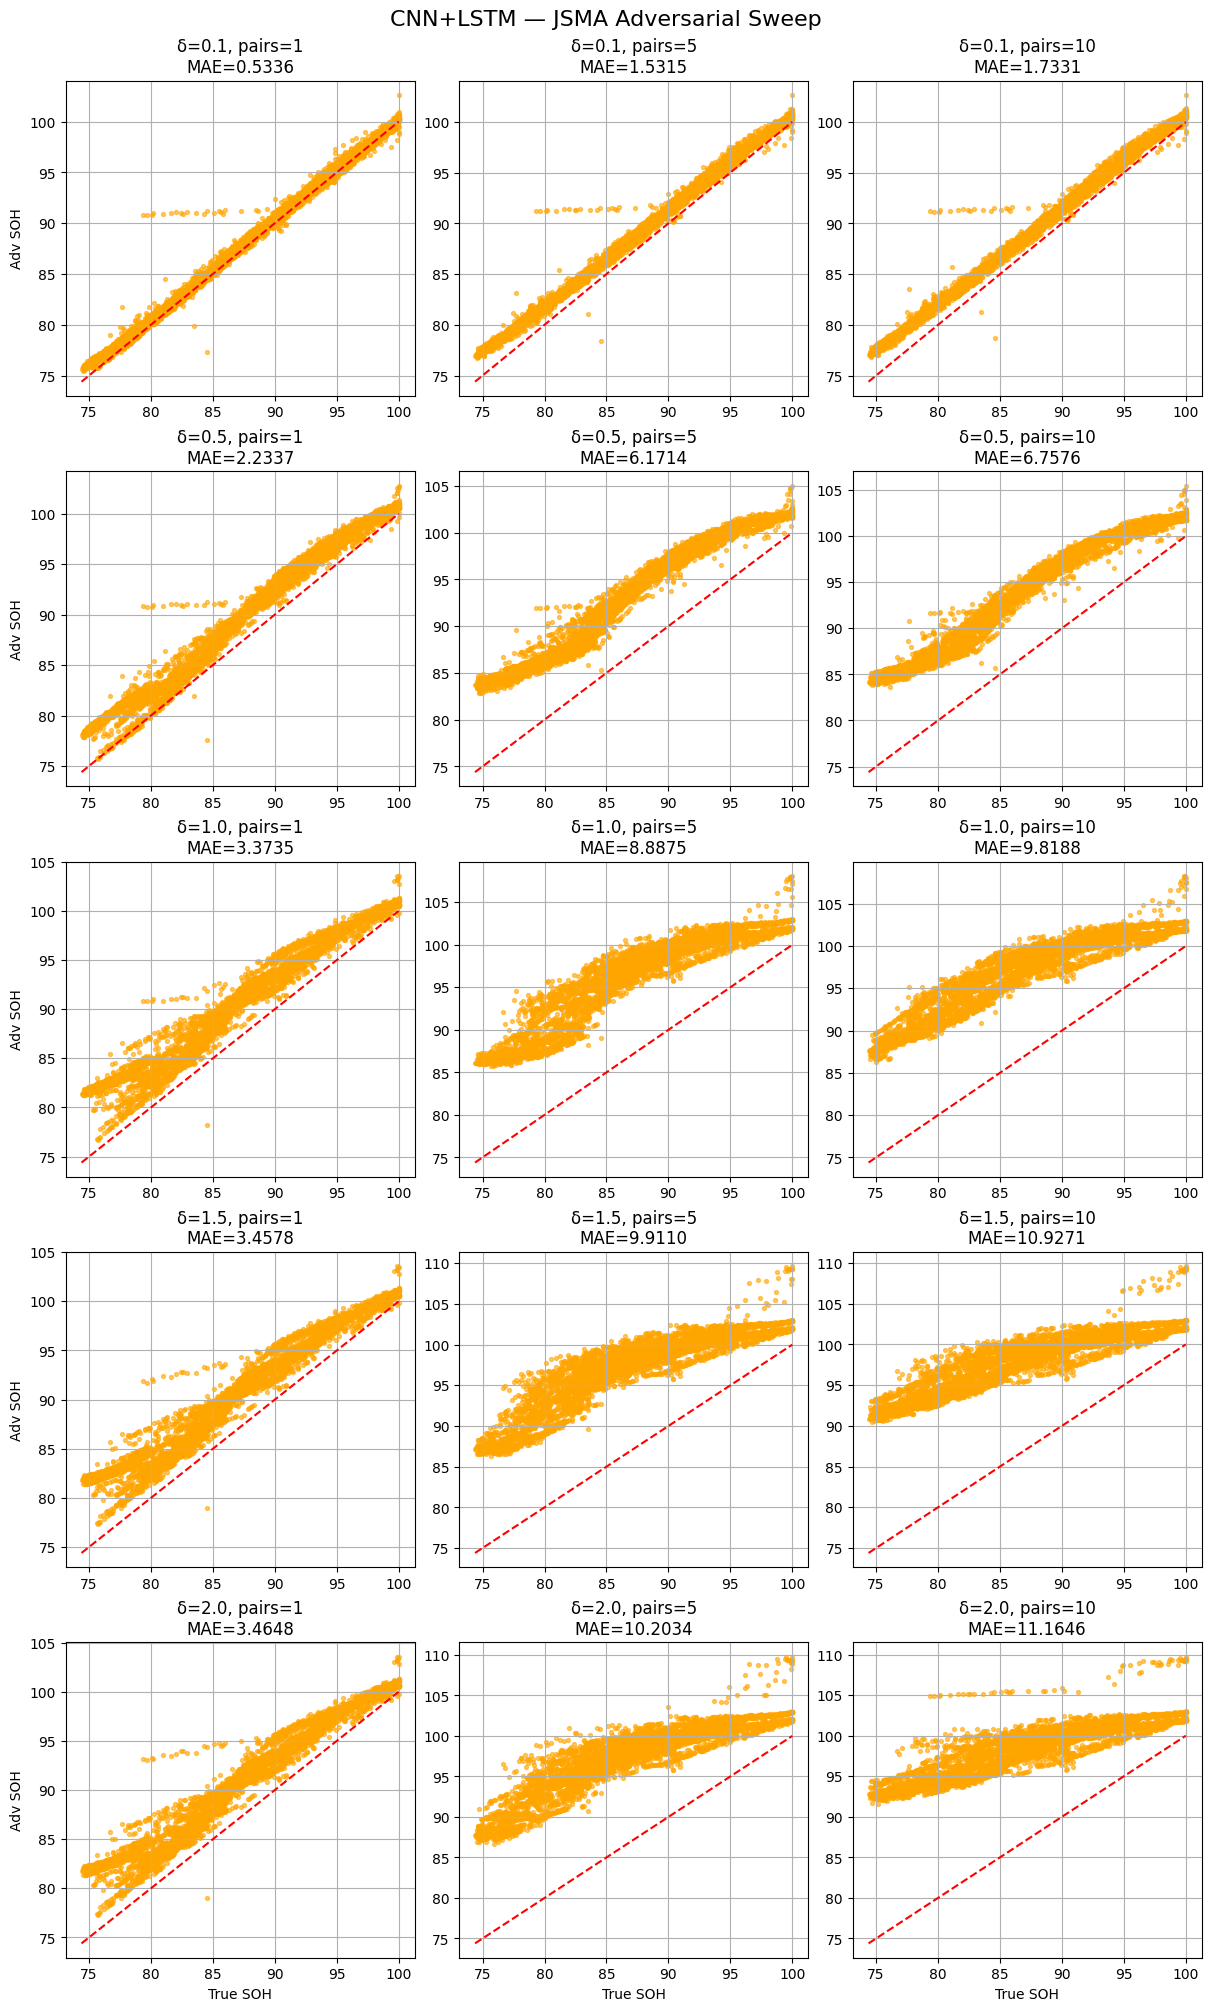


=== JSMA Attack Results : CNN+LSTM ===
  Delta    Pairs        MSE       MAE       ΔMSE      ΔMAE    Robustness
-------  -------  ---------  --------  ---------  --------  ------------
0.10000        1    0.66849   0.53362    0.51333   0.26127       0.04066
0.10000        5    2.82763   1.53148    2.67248   1.25913      -3.62326
0.10000       10    3.48768   1.73311    3.33252   1.46076      -4.36361
0.50000        1    6.00863   2.23375    5.85348   1.96140      -6.20184
0.50000        5   40.37515   6.17137   40.21999   5.89902     -20.65993
0.50000       10   48.34763   6.75762   48.19248   6.48527     -22.81249
1.00000        1   13.63095   3.37352   13.47580   3.10117     -10.38683
1.00000        5   86.15938   8.88748   86.00423   8.61513     -30.63289
1.00000       10  105.97522   9.81878  105.82007   9.54643     -34.05241
1.50000        1   14.23505   3.45778   14.07990   3.18543     -10.69622
1.50000        5  108.92612   9.91095  108.77097   9.63861     -34.39086
1.50000    

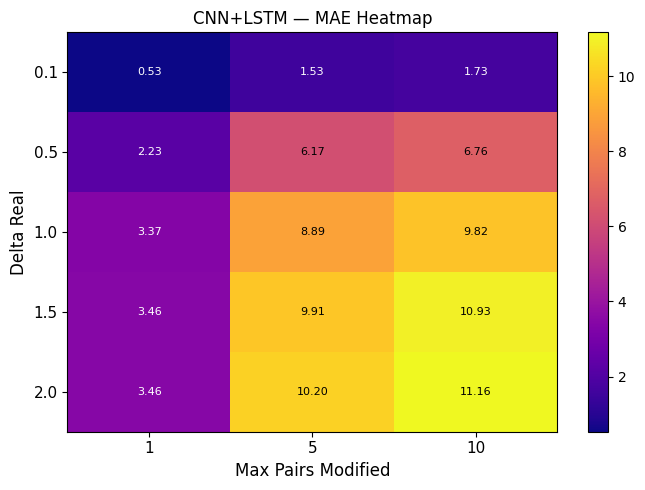

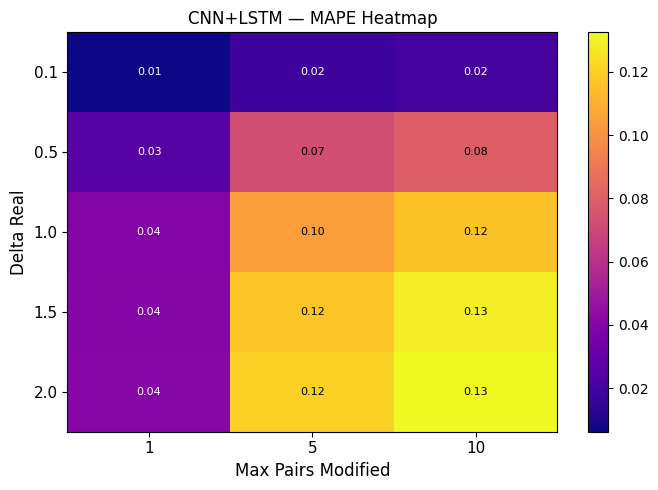

In [49]:
print("--------")
print("CNN+LSTM")
print("--------")

cnn_lstm = keras.models.load_model("../../Models/CNN_LSTM_NT.keras")

MAE_map, MAPE_map, table = attack_evaluation(
    model=cnn_lstm,
    model_name="CNN+LSTM",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    deltas=[0.1, 0.5, 1.0, 1.5, 2.0],
    pairs_list=[1, 5, 10],
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)


--------
CNN+GRU
--------


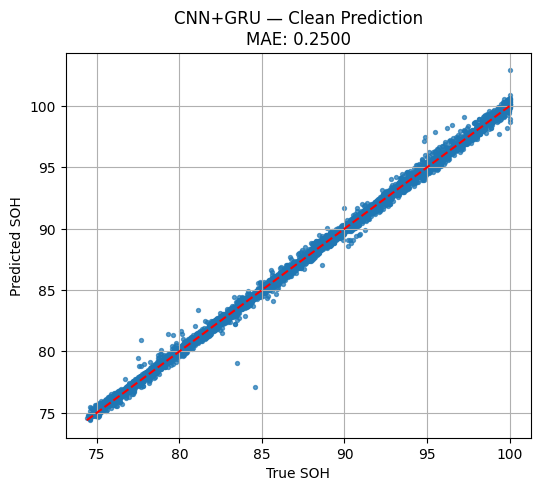

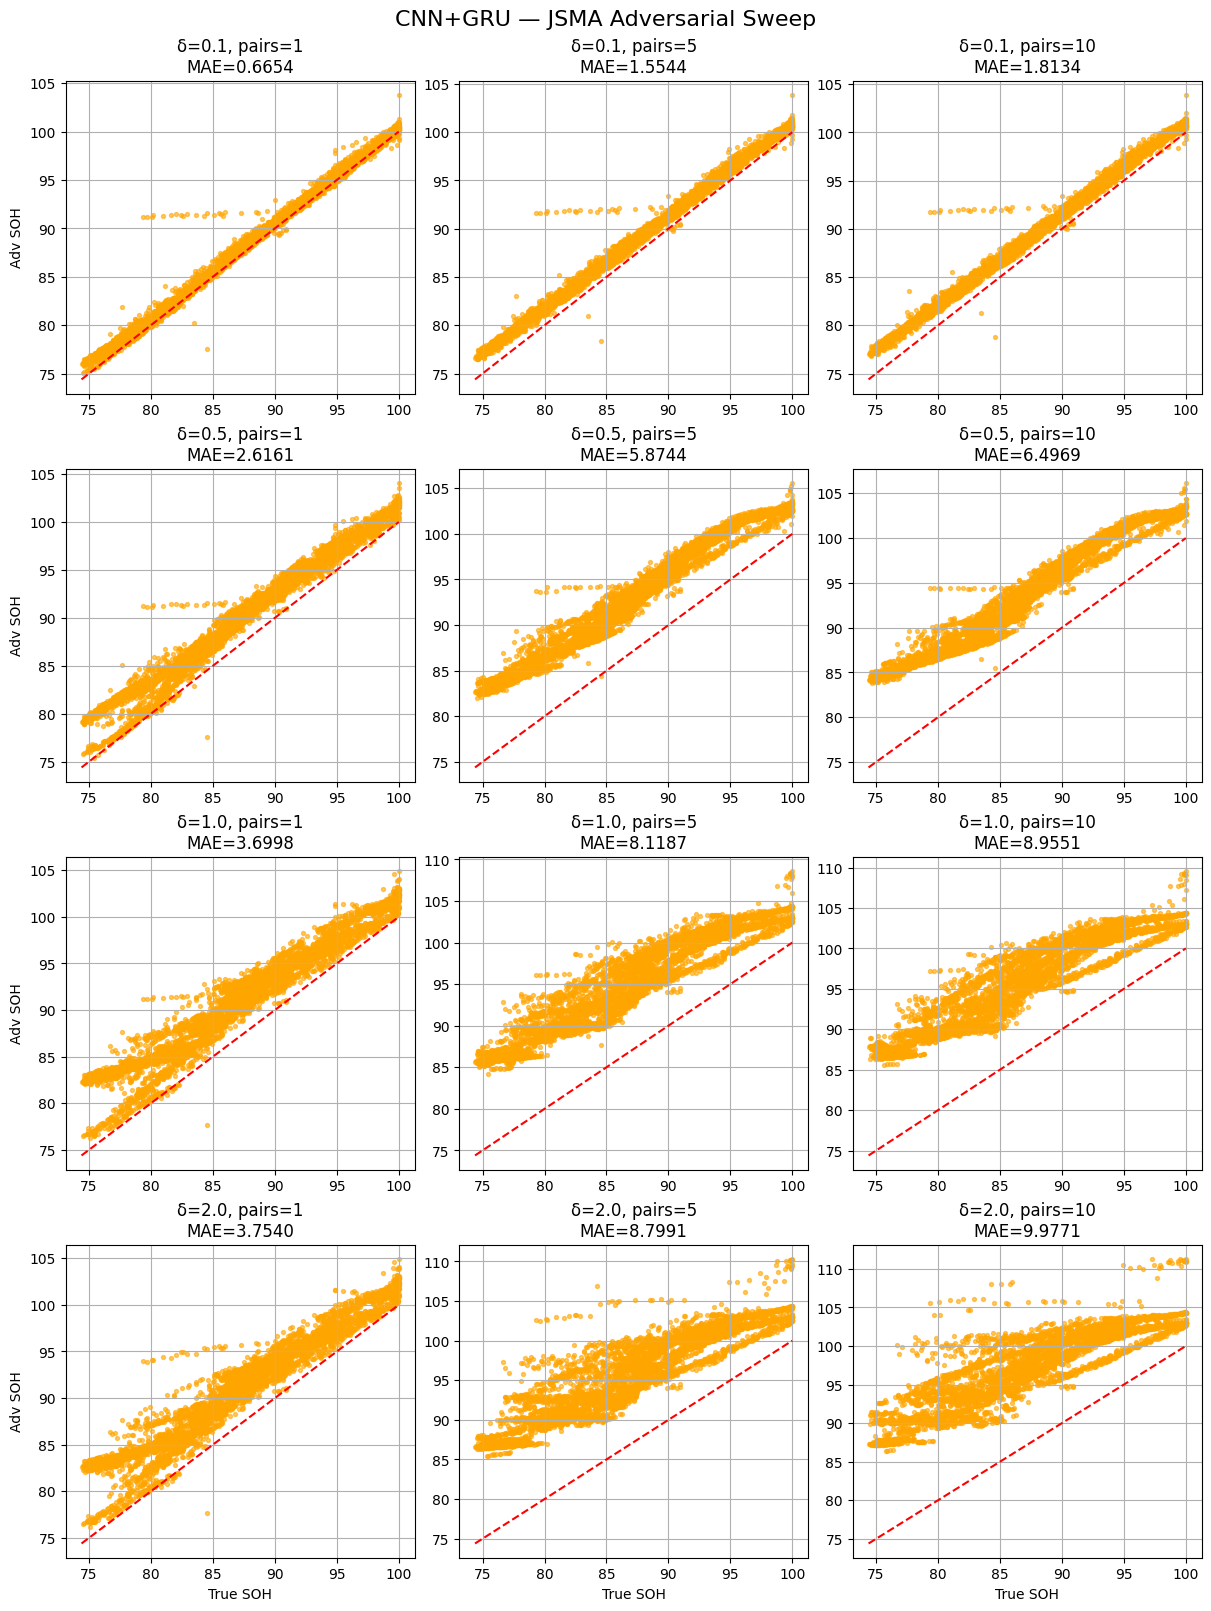


=== JSMA Attack Results : CNN+GRU ===
  Delta    Pairs        MSE      MAE       ΔMSE     ΔMAE    Robustness
-------  -------  ---------  -------  ---------  -------  ------------
0.10000        1    0.88331  0.66542    0.75257  0.41544      -0.66189
0.10000        5    2.88340  1.55444    2.75266  1.30446      -4.21825
0.10000       10    3.78650  1.81339    3.65576  1.56341      -5.25412
0.50000        1    8.12075  2.61611    7.99000  2.36613      -8.46525
0.50000        5   36.33486  5.87440   36.20412  5.62442     -21.49943
0.50000       10   44.66505  6.49686   44.53430  6.24688     -23.98945
1.00000        1   16.68564  3.69980   16.55490  3.44982     -12.80036
1.00000        5   71.40081  8.11871   71.27007  7.86873     -30.47737
1.00000       10   86.82305  8.95506   86.69231  8.70508     -33.82303
2.00000        1   17.34584  3.75399   17.21510  3.50401     -13.01714
2.00000        5   86.07999  8.79909   85.94925  8.54911     -33.19908
2.00000       10  110.98954  9.97711  

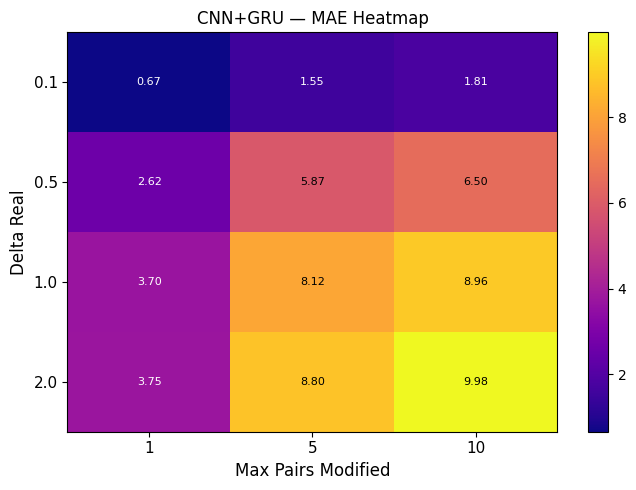

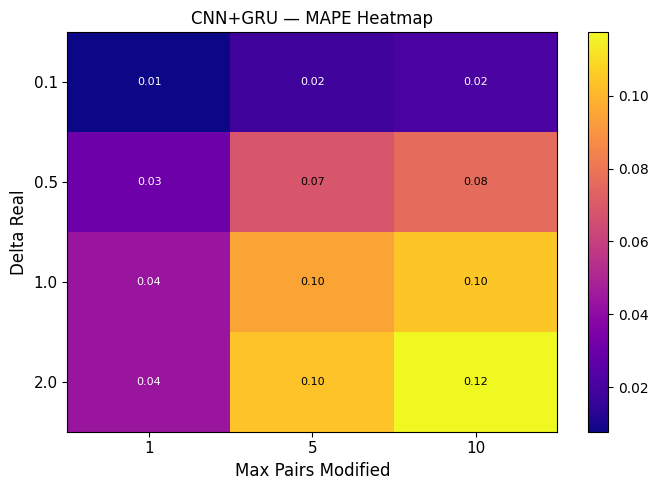

In [46]:
print("--------")
print("CNN+GRU")
print("--------")

cnn_gru = keras.models.load_model("../../Models/CNN_GRU_NT.keras")

MAE_map, MAPE_map, table = attack_evaluation(
    model=cnn_gru,
    model_name="CNN+GRU",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    deltas=[0.1, 0.5, 1.0, 2.0],
    pairs_list=[1, 5, 10],
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)


--------
CNN+GRU AT
--------


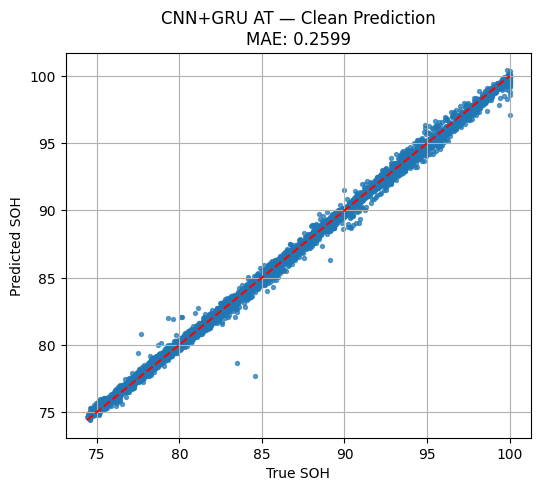

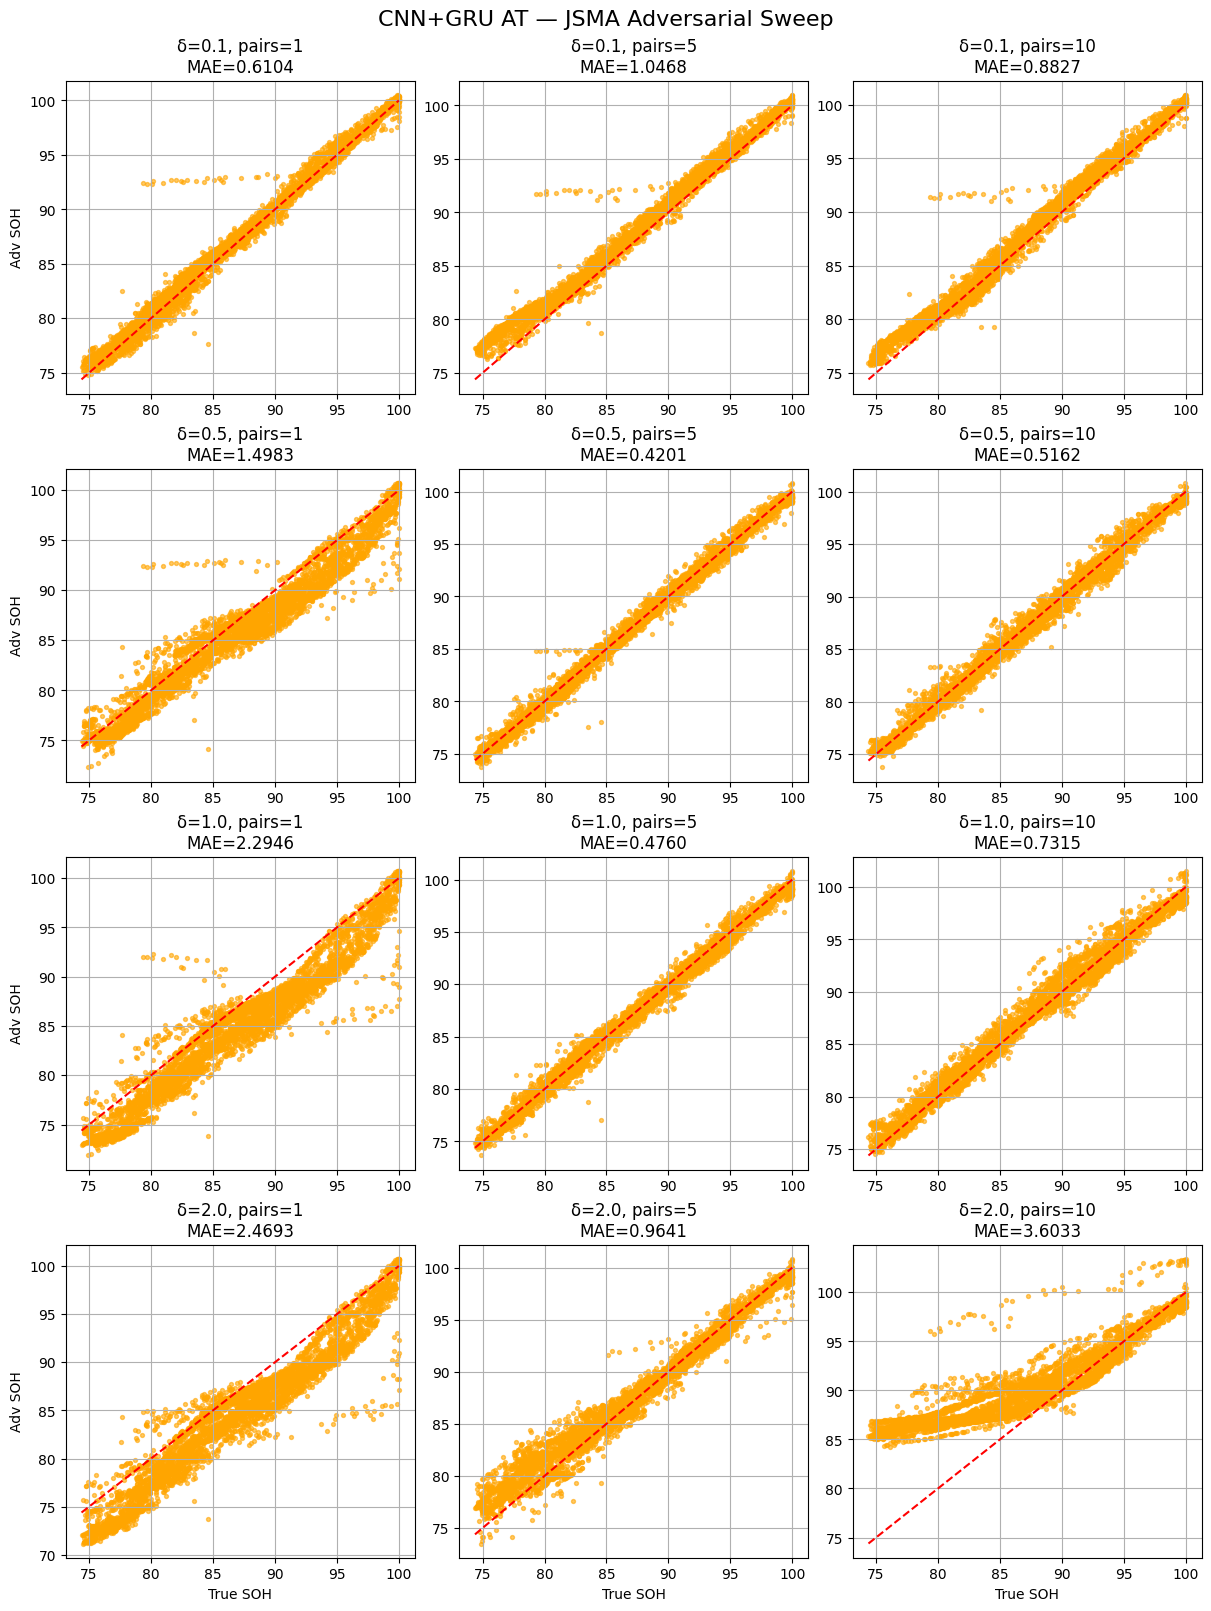


=== JSMA Attack Results : CNN+GRU AT ===
  Delta    Pairs       MSE      MAE      ΔMSE     ΔMAE
-------  -------  --------  -------  --------  -------
0.10000        1   0.93635  0.61038   0.79817  0.35052
0.10000        5   1.83937  1.04682   1.70119  0.78696
0.10000       10   1.35180  0.88273   1.21363  0.62287
0.50000        1   3.77083  1.49826   3.63266  1.23840
0.50000        5   0.34529  0.42008   0.20712  0.16022
0.50000       10   0.48878  0.51620   0.35061  0.25634
1.00000        1   7.65435  2.29461   7.51617  2.03475
1.00000        5   0.40175  0.47596   0.26357  0.21610
1.00000       10   0.90202  0.73154   0.76385  0.47168
2.00000        1   8.77037  2.46933   8.63219  2.20947
2.00000        5   1.79537  0.96406   1.65720  0.70420
2.00000       10  23.44981  3.60326  23.31164  3.34340


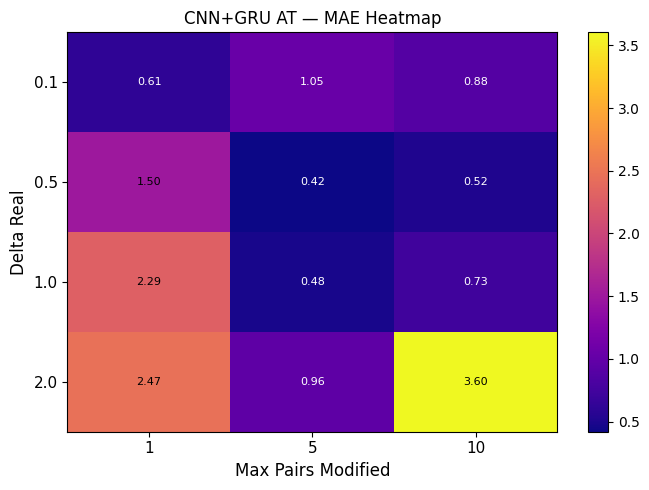

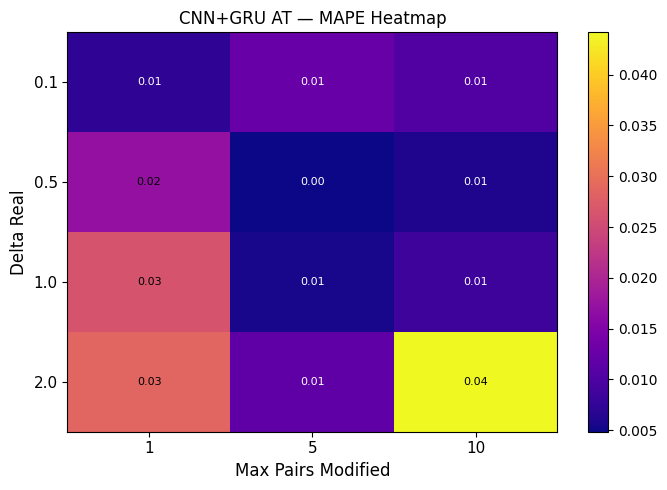

In [12]:
print("--------")
print("CNN+GRU AT")
print("--------")

cnn_gru = keras.models.load_model(r"C:\Users\saman\Downloads\CNN_GRU_JSMA_AT(1).keras")

MAE_map, MAPE_map, table = attack_evaluation(
    model=cnn_gru,
    model_name="CNN+GRU AT",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    deltas=[0.1, 0.5, 1.0, 2.0],
    pairs_list=[1, 5, 10],
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)


---
CNN
---


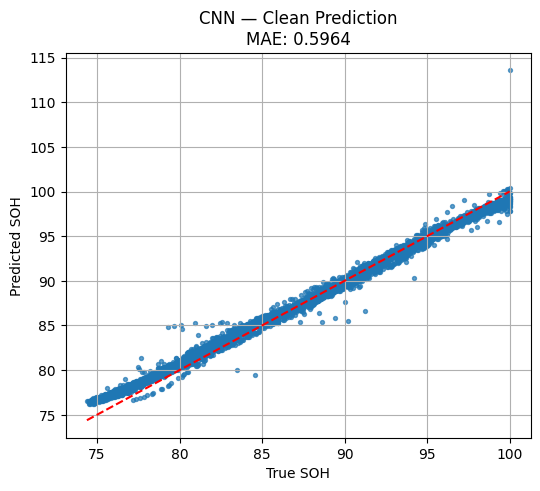

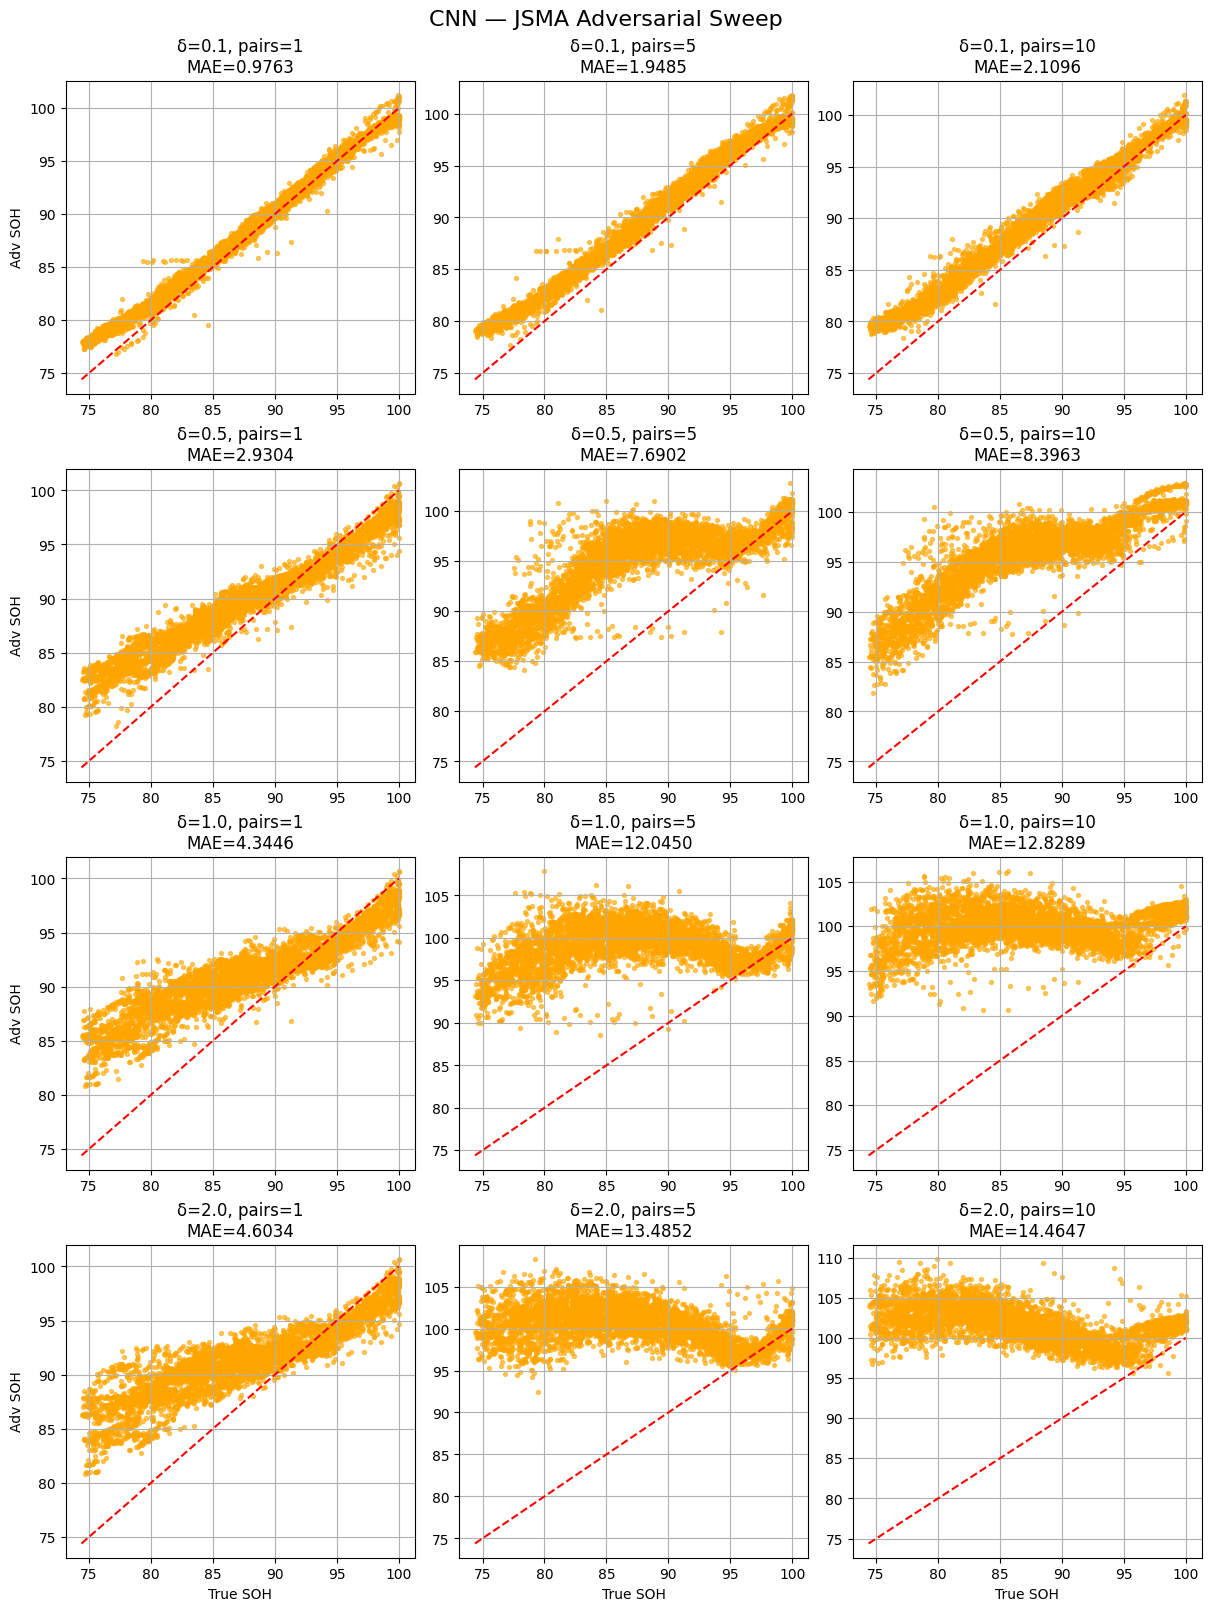


=== JSMA Attack Results : CNN ===
  Delta    Pairs        MSE       MAE       ΔMSE      ΔMAE    Robustness
-------  -------  ---------  --------  ---------  --------  ------------
0.10000        1    1.58055   0.97628    0.94991   0.37991       0.36296
0.10000        5    4.69415   1.94846    4.06351   1.35209      -1.26721
0.10000       10    5.78428   2.10957    5.15364   1.51319      -1.53734
0.50000        1   12.90685   2.93036   12.27621   2.33399      -2.91365
0.50000        5   74.54084   7.69018   73.91020   7.09381     -10.89497
0.50000       10   84.71167   8.39630   84.08103   7.79993     -12.07900
1.00000        1   28.02054   4.34464   27.38990   3.74827      -5.28514
1.00000        5  186.53620  12.04502  185.90555  11.44865     -18.19721
1.00000       10  208.56024  12.82890  207.92959  12.23253     -19.51164
2.00000        1   32.22136   4.60340   31.59072   4.00703      -5.71902
2.00000        5  240.05373  13.48516  239.42308  12.88879     -20.61205
2.00000       10

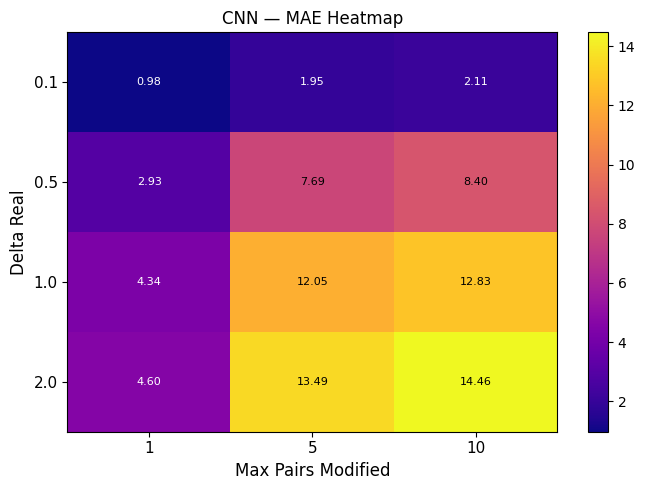

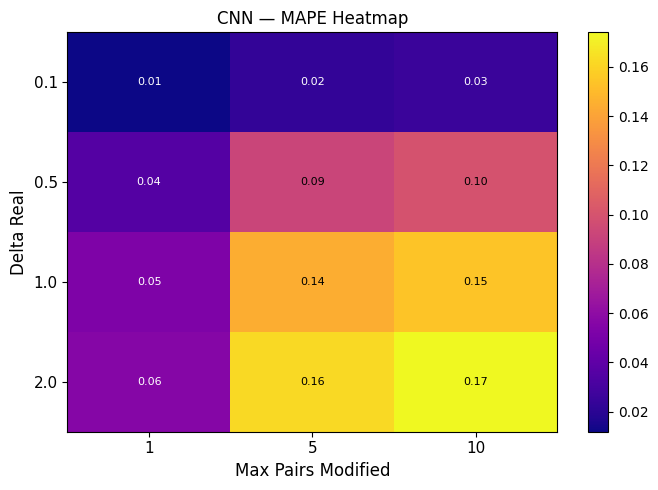

In [47]:
print("---")
print("CNN")
print("---")

cnn = keras.models.load_model("../../Models/CNN_NT.keras")

MAE_map, MAPE_map, table = attack_evaluation(
    model=cnn,
    model_name="CNN",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    deltas=[0.1, 0.5, 1.0, 2.0],
    pairs_list=[1, 5, 10],
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)


--------
RCN
--------


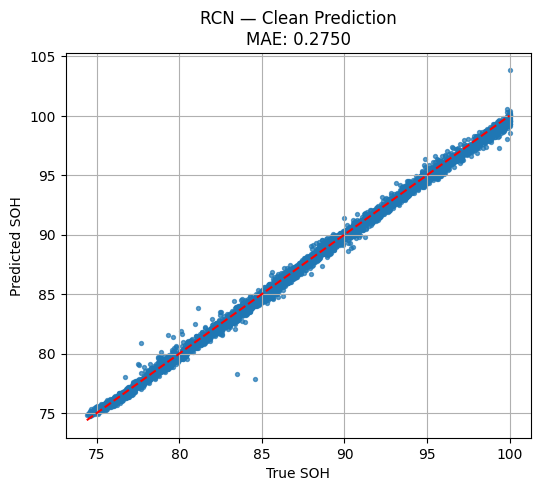

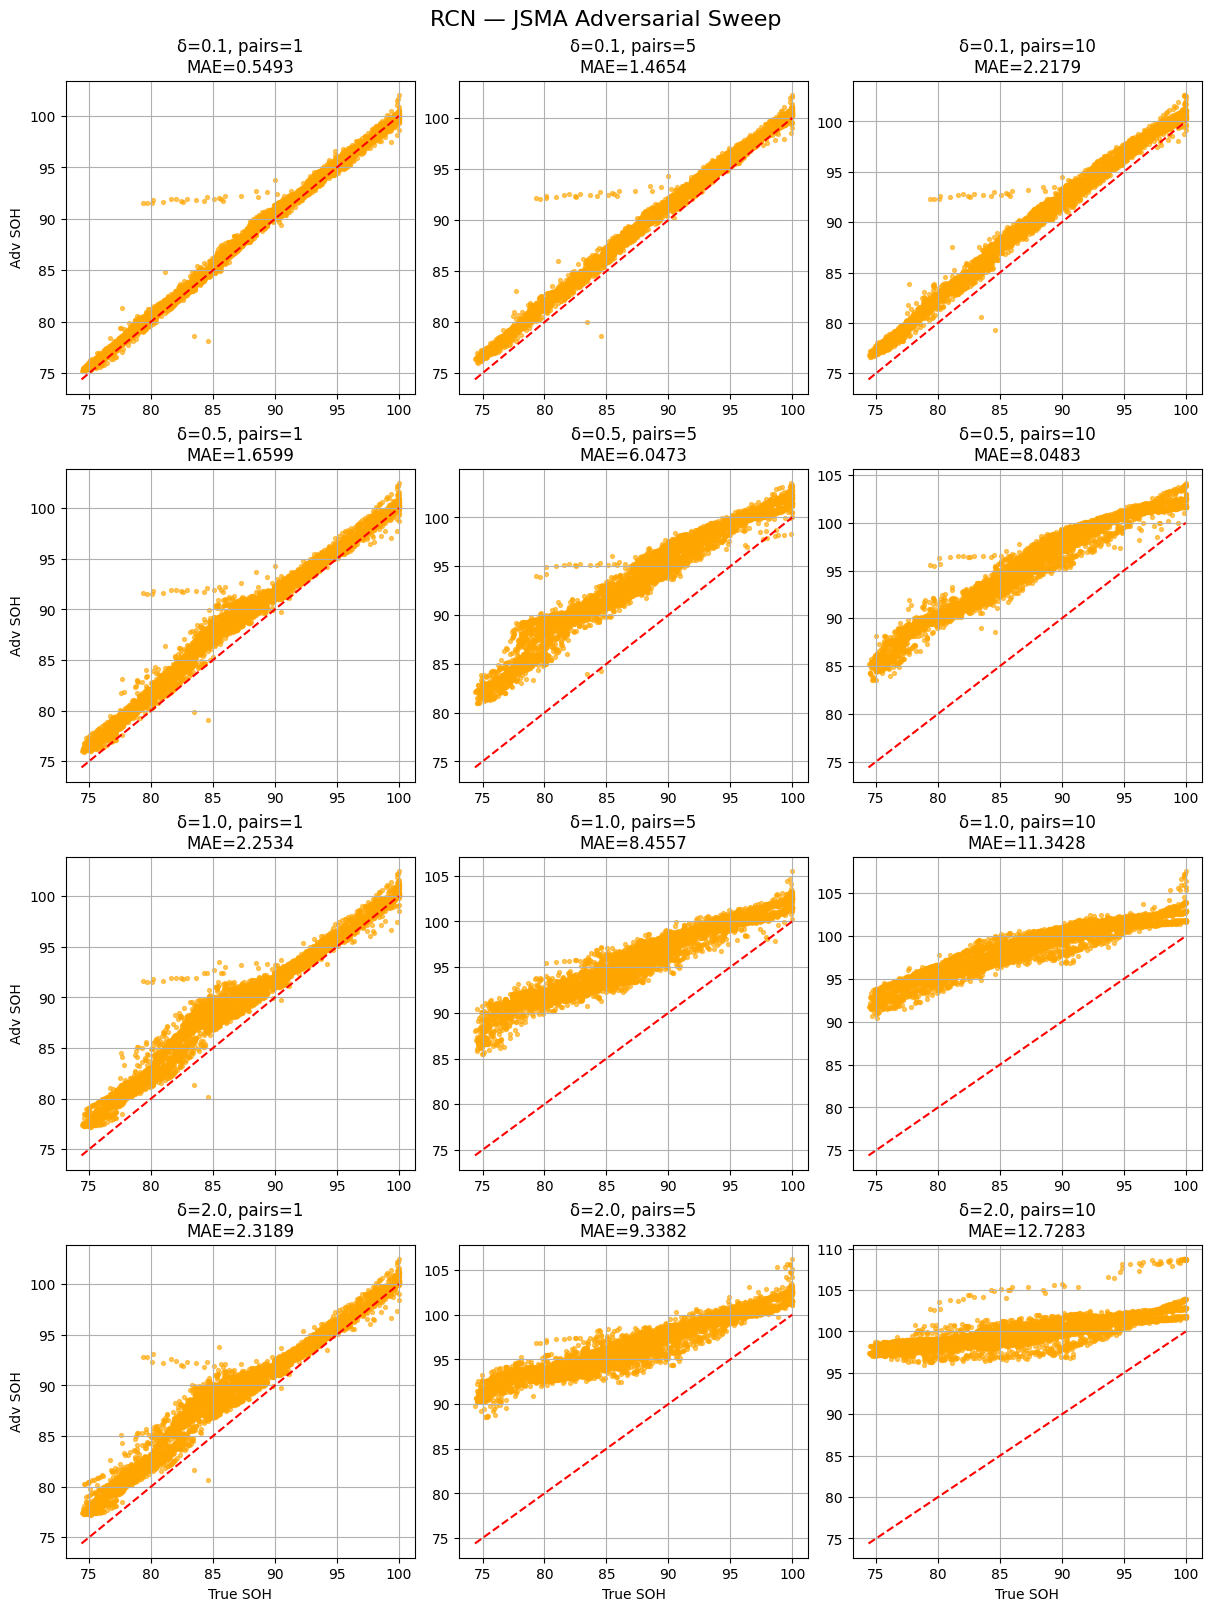


=== JSMA Attack Results : RCN ===
  Delta    Pairs        MSE       MAE       ΔMSE      ΔMAE    Robustness
-------  -------  ---------  --------  ---------  --------  ------------
0.10000        1    0.73296   0.54930    0.58101   0.27429       0.00259
0.10000        5    2.71420   1.46539    2.56224   1.19039      -3.32858
0.10000       10    5.59431   2.21790    5.44236   1.94289      -6.06491
0.50000        1    3.76648   1.65990    3.61453   1.38489      -4.03585
0.50000        5   40.12329   6.04729   39.97134   5.77229     -19.98965
0.50000       10   69.98475   8.04834   69.83279   7.77334     -27.26604
1.00000        1    6.90861   2.25343    6.75666   1.97842      -6.19410
1.00000        5   81.82698   8.45566   81.67503   8.18066     -28.74716
1.00000       10  145.58558  11.34275  145.43363  11.06775     -39.24544
2.00000        1    7.39183   2.31886    7.23988   2.04385      -6.43202
2.00000        5  102.67137   9.33820  102.51942   9.06319     -31.95632
2.00000       10

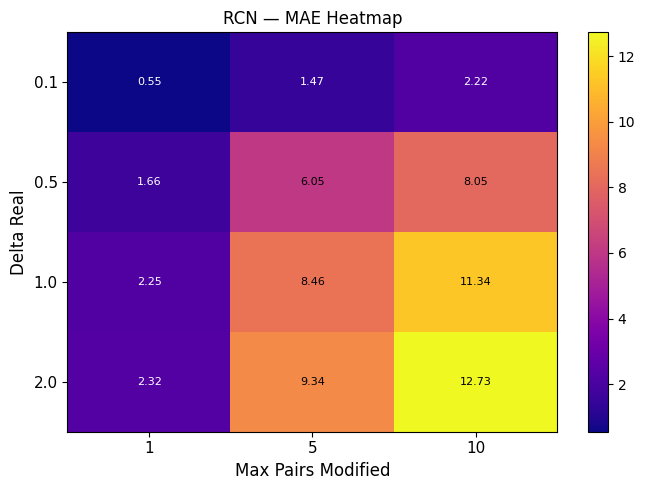

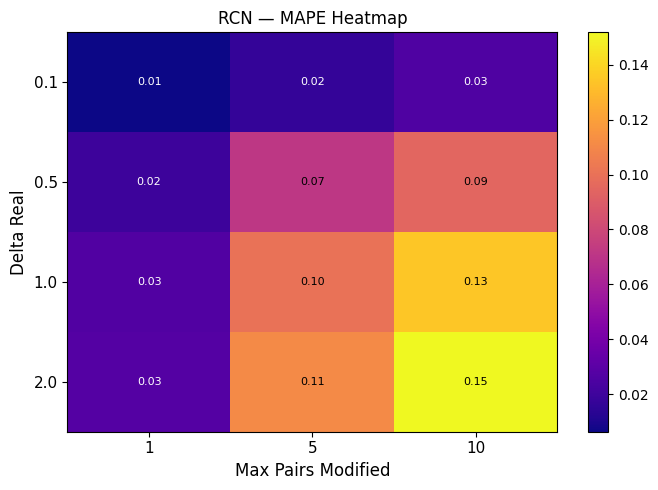

In [48]:
print("--------")
print("RCN")
print("--------")

rcn = keras.models.load_model("../../Models/RCN_NT.keras")

MAE_map, MAPE_map, table = attack_evaluation(
    model=rcn,
    model_name="RCN",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    deltas=[0.1, 0.5, 1.0, 2.0],
    pairs_list=[1, 5, 10],
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)


--------
RCN
--------


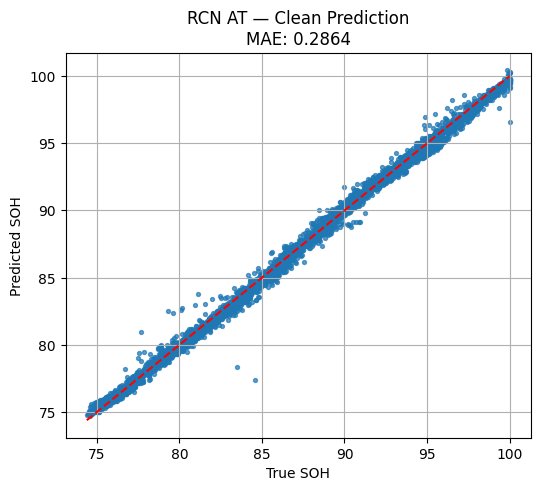

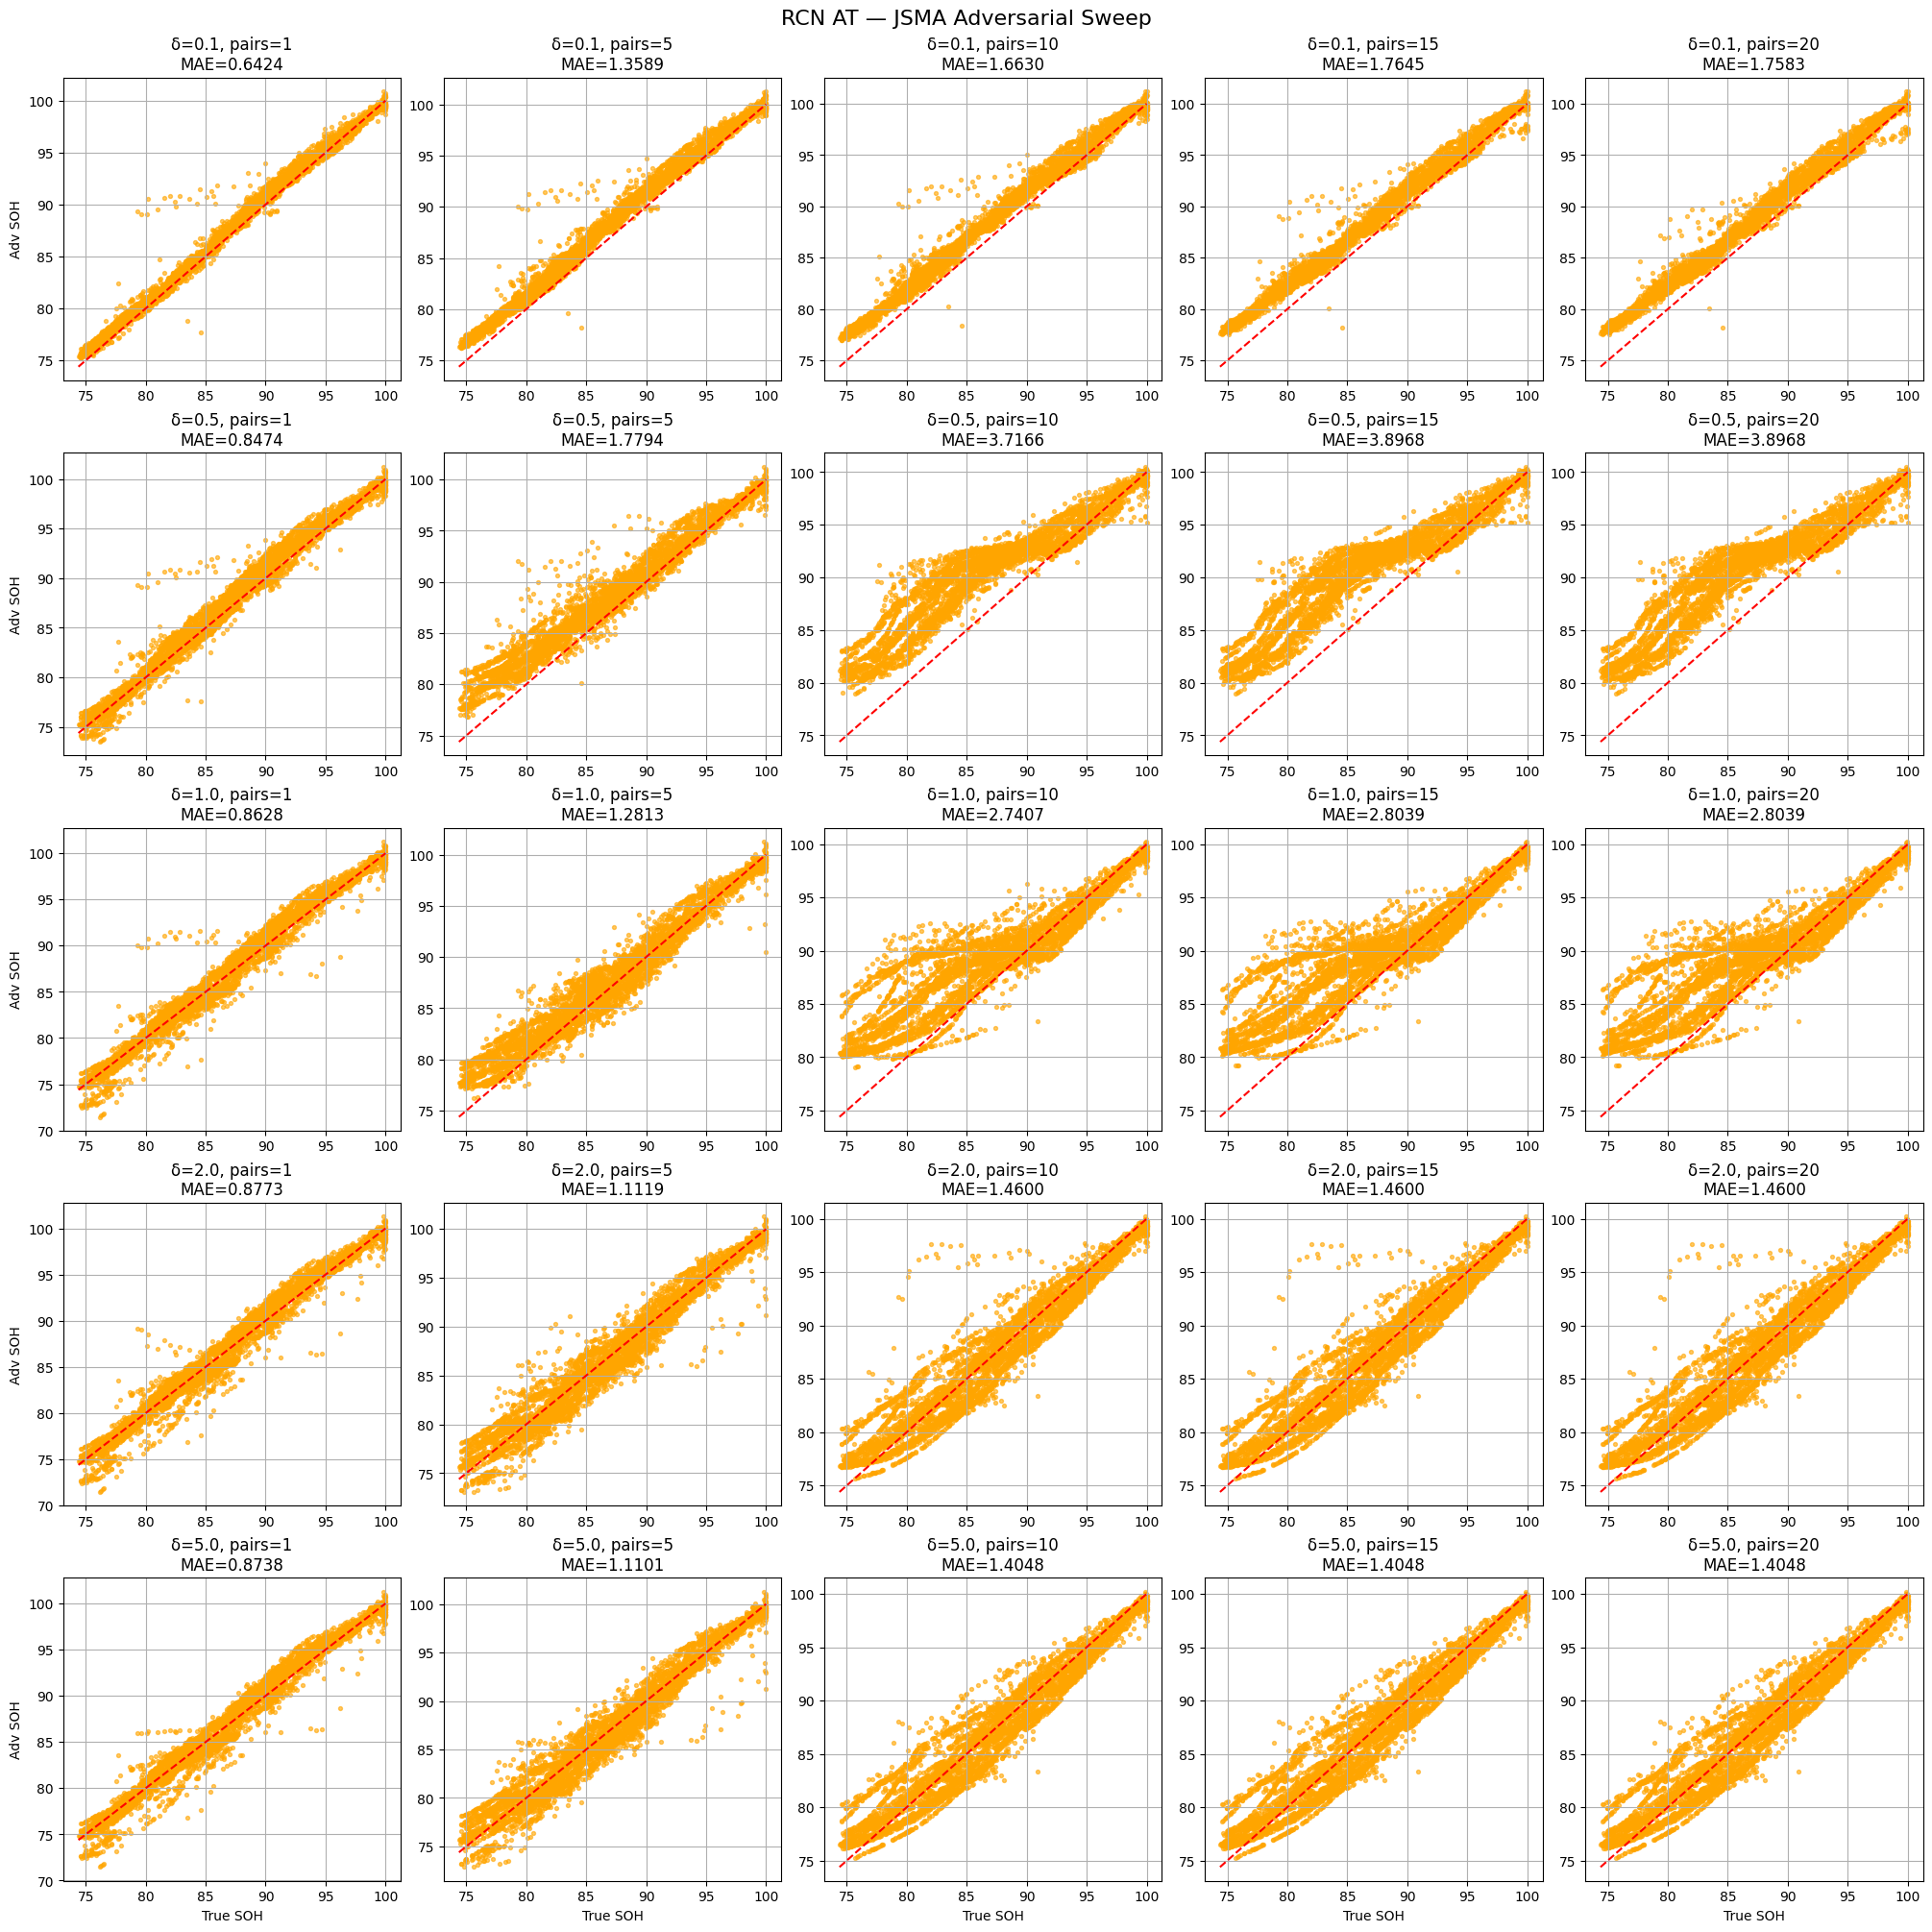


=== JSMA Attack Results : RCN AT ===
  Delta    Pairs       MSE      MAE      ΔMSE     ΔMAE    Robustness
-------  -------  --------  -------  --------  -------  ------------
0.10000        1   0.80992  0.64239   0.64111  0.35599      -0.24300
0.10000        5   2.49271  1.35892   2.32391  1.07253      -2.74491
0.10000       10   3.55155  1.66301   3.38275  1.37661      -3.80667
0.10000       15   3.98686  1.76446   3.81806  1.47806      -4.16088
0.10000       20   3.90251  1.75830   3.73371  1.47190      -4.13939
0.50000        1   1.33199  0.84738   1.16318  0.56098      -0.95875
0.50000        5   5.24235  1.77937   5.07354  1.49298      -4.21297
0.50000       10  19.49282  3.71660  19.32401  3.43020     -10.97711
0.50000       15  21.21409  3.89683  21.04528  3.61043     -11.60640
0.50000       20  21.21409  3.89683  21.04528  3.61043     -11.60640
1.00000        1   1.43381  0.86280   1.26501  0.57641      -1.01261
1.00000        5   2.88351  1.28129   2.71471  0.99489      -2.47

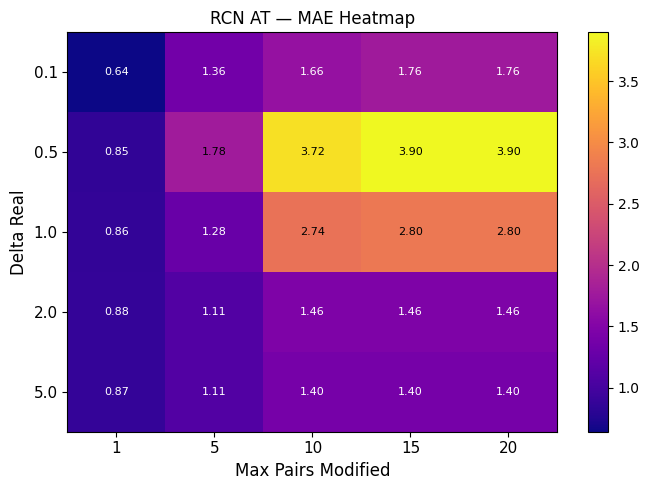

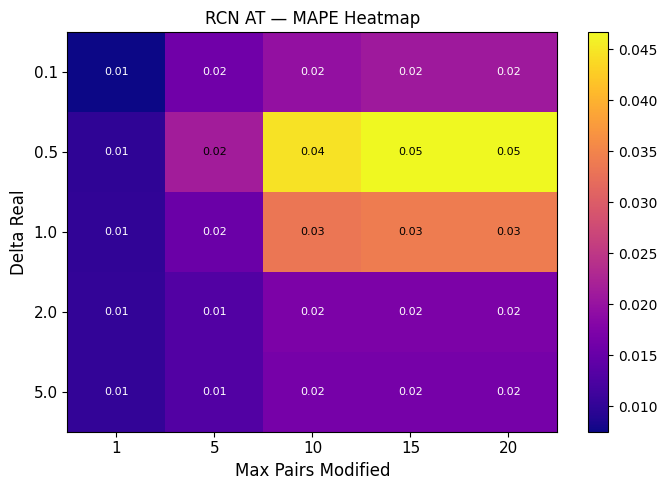

In [44]:
print("--------")
print("RCN")
print("--------")

rcn_at = keras.models.load_model(r"C:\Users\saman\Downloads\RCN_JSMA_AT_2.keras")

MAE_map, MAPE_map, table = attack_evaluation(
    model=rcn_at,
    model_name="RCN AT",
    x_ic=X_ic_test,
    x_ctx=X_context_test,
    y_true_norm=y_test_tf,
    deltas=[0.1, 0.5, 1.0, 2.0, 5.0],
    pairs_list=[1, 5, 10, 15, 20],
    scaler_std=preprocessor.ic_scaler.scale_,
    clip_min=clip_min,
    clip_max=clip_max,
    y_std=y_std,
    y_mean=y_mean,
)
